In [1]:
!pip install -q optuna shap xgboost scikit-learn pandas matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.0 MB/s eta 0:00:00


In [2]:
import os, warnings
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap
import optuna
import xgboost as xgb

from sklearn.model_selection  import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing    import StandardScaler, OneHotEncoder
from sklearn.compose          import ColumnTransformer
from sklearn.ensemble         import RandomForestClassifier
from sklearn.metrics          import (
    accuracy_score, recall_score, precision_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
)

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)


In [3]:
RANDOM_STATE    = 42
DATA_PATH       = "dataset/heart_statlog_cleveland_hungary_final.csv"
TARGET          = "target"          # 1 = Disease, 0 = Healthy
TEST_SIZE       = 0.20
CV_FOLDS        = 5
N_OPTUNA_TRIALS = 80                # matches XG_Boost notebook (50–100)
FIG_DPI         = 130

np.random.seed(RANDOM_STATE)

plt.rcParams.update({
    "figure.dpi"       : FIG_DPI,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "font.family"      : "DejaVu Sans",
})

# Colour palette (mirrors XG_Boost notebook aesthetic)
PALETTE = {
    "xgb"      : "#E8724C",   # orange  – optimised XGBoost
    "rf"       : "#4C9BE8",   # blue    – Random Forest
    "baseline" : "#4C9BE8",
}

print("=" * 70)
print("  HEART DISEASE CLASSIFICATION — XGBoost (Optuna) vs. Random Forest")
print("=" * 70)


  HEART DISEASE CLASSIFICATION — XGBoost (Optuna) vs. Random Forest


In [4]:
def maybe_upload(path: str) -> None:
    if os.path.exists(path):
        print(f"[✓] Dataset found: {path}")
        return
    try:
        from google.colab import files as colab_files  # type: ignore
        print("[!] Dataset missing — please upload 'heart_statlog_cleveland_hungary_final.csv'")
        uploaded = colab_files.upload()
        os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
        os.rename(list(uploaded.keys())[0], path)
        print(f"[✓] Saved to: {path}")
    except ImportError:
        raise FileNotFoundError(
            f"Dataset not found at '{path}'. "
            "Place the CSV inside a 'dataset/' folder."
        )

maybe_upload(DATA_PATH)

[✓] Dataset found: dataset/heart_statlog_cleveland_hungary_final.csv


In [5]:
df = pd.read_csv(DATA_PATH)

print(f"\n[1/7] Dataset loaded")
print(f"      Shape         : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"      Missing values: {df.isnull().sum().sum()}")
print(f"      Target balance:\n{df[TARGET].value_counts().rename({0:'No Disease',1:'Disease'})}\n")



[1/7] Dataset loaded
      Shape         : 1190 rows × 12 columns
      Missing values: 0
      Target balance:
target
Disease       629
No Disease    561
Name: count, dtype: int64



In [6]:
CATEGORICAL_FEATURES = [
    "sex",                  # 0 = Female, 1 = Male
    "chest pain type",      # 1–4 nominal
    "fasting blood sugar",  # binary
    "resting ecg",          # 0–2 ordinal
    "exercise angina",      # binary
    "ST slope",             # 0–2 ordinal
]

NUMERICAL_FEATURES = [
    "age",
    "resting bp s",
    "cholesterol",
    "max heart rate",
    "oldpeak",
]

X_raw = df.drop(columns=[TARGET])   # raw (used by RF — no scaling)
y     = df[TARGET]

In [7]:
print("[2/7] Splitting data (80/20 stratified)")

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y,
    test_size    = TEST_SIZE,
    random_state = RANDOM_STATE,
    stratify     = y,
)

print(f"      Train: {X_train_raw.shape[0]} | Test: {X_test_raw.shape[0]}")
print(f"      Train balance → {dict(y_train.value_counts())}")
print(f"      Test  balance → {dict(y_test.value_counts())}\n")



[2/7] Splitting data (80/20 stratified)
      Train: 952 | Test: 238
      Train balance → {1: np.int64(503), 0: np.int64(449)}
      Test  balance → {1: np.int64(126), 0: np.int64(112)}



In [8]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(),                                  NUMERICAL_FEATURES),
        ("cat", OneHotEncoder(drop="first", sparse_output=False),  CATEGORICAL_FEATURES),
    ],
    remainder="drop",
)

X_train_proc = preprocessor.fit_transform(X_train_raw)
X_test_proc  = preprocessor.transform(X_test_raw)

# Recover human-readable feature names (needed for SHAP axis labels)
cat_names    = preprocessor.named_transformers_["cat"] \
                            .get_feature_names_out(CATEGORICAL_FEATURES).tolist()
FEATURE_NAMES = NUMERICAL_FEATURES + cat_names
print(f"[✓] Preprocessed feature count: {len(FEATURE_NAMES)}")
print(f"    Features: {FEATURE_NAMES}\n")


[✓] Preprocessed feature count: 16
    Features: ['age', 'resting bp s', 'cholesterol', 'max heart rate', 'oldpeak', 'sex_1', 'chest pain type_2', 'chest pain type_3', 'chest pain type_4', 'fasting blood sugar_1', 'resting ecg_1', 'resting ecg_2', 'exercise angina_1', 'ST slope_1', 'ST slope_2', 'ST slope_3']



In [9]:
print("[3/7] Training Random Forest (baseline — exact notebook config)")

rf_model = RandomForestClassifier(
    n_estimators     = 100,
    max_depth        = 15,
    min_samples_split= 2,
    min_samples_leaf = 1,
    max_features     = "sqrt",
    bootstrap        = True,
    class_weight     = "balanced",
    random_state     = RANDOM_STATE,
    n_jobs           = -1,
)
rf_model.fit(X_train_raw, y_train)
print("      [✓] Random Forest trained.\n")

[3/7] Training Random Forest (baseline — exact notebook config)
      [✓] Random Forest trained.



In [10]:
def objective(trial: optuna.Trial) -> float:
    """
    Maximise mean AUC-ROC across 5 stratified folds.
    AUC-ROC is preferred over accuracy because it reflects the model's
    ability to rank diseased vs. healthy patients — critical in medical
    screening where missing a disease (false negative) is most costly.
    """
    params = {
        "objective"        : "binary:logistic",
        "eval_metric"      : "logloss",
        "random_state"     : RANDOM_STATE,
        "n_estimators"     : trial.suggest_int  ("n_estimators",    50,  500),
        "max_depth"        : trial.suggest_int  ("max_depth",        3,   10),
        "learning_rate"    : trial.suggest_float("learning_rate",  0.01, 0.3,  log=True),
        "subsample"        : trial.suggest_float("subsample",       0.5,  1.0),
        "colsample_bytree" : trial.suggest_float("colsample_bytree",0.5,  1.0),
        "min_child_weight" : trial.suggest_int  ("min_child_weight", 1,   10),
        "gamma"            : trial.suggest_float("gamma",            0,    5),
        "reg_alpha"        : trial.suggest_float("reg_alpha",        0,    1),
        "reg_lambda"       : trial.suggest_float("reg_lambda",       0.5,  5),
    }
    model = xgb.XGBClassifier(**params)
    skf   = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(model, X_train_proc, y_train,
                             cv=skf, scoring="roc_auc", n_jobs=-1)
    return scores.mean()



In [11]:
print("[4/7] Running Optuna hyperparameter search (XGBoost)")
print(f"      Trials: {N_OPTUNA_TRIALS} | CV folds: {CV_FOLDS} | Metric: AUC-ROC")

study = optuna.create_study(
    direction  = "maximize",
    study_name = "xgboost_heart_hpo",
    sampler    = optuna.samplers.TPESampler(seed=RANDOM_STATE),
)
study.optimize(objective, n_trials=N_OPTUNA_TRIALS, show_progress_bar=True)

best_params = study.best_params
best_params.update({
    "objective"   : "binary:logistic",
    "eval_metric" : "logloss",
    "random_state": RANDOM_STATE,
})

print(f"\n      [✓] Best CV AUC-ROC : {study.best_value:.4f}")
print(f"      Best params      : {best_params}\n")


[4/7] Running Optuna hyperparameter search (XGBoost)
      Trials: 80 | CV folds: 5 | Metric: AUC-ROC


  0%|          | 0/80 [00:00<?, ?it/s]


      [✓] Best CV AUC-ROC : 0.9504
      Best params      : {'n_estimators': 356, 'max_depth': 7, 'learning_rate': 0.127397824177842, 'subsample': 0.6148985575257964, 'colsample_bytree': 0.6639400789323814, 'min_child_weight': 1, 'gamma': 0.022904229688582595, 'reg_alpha': 0.7268865388800891, 'reg_lambda': 4.46727253981053, 'objective': 'binary:logistic', 'eval_metric': 'logloss', 'random_state': 42}



In [12]:
print("[5/7] Training final XGBoost on full training set")
optimized_model = xgb.XGBClassifier(**best_params)
optimized_model.fit(X_train_proc, y_train)
print("      [✓] XGBoost (Optuna-Optimised) trained.\n")


[5/7] Training final XGBoost on full training set
      [✓] XGBoost (Optuna-Optimised) trained.



In [13]:
def compute_metrics(y_true, y_pred, y_prob, label: str) -> dict:
    """
    Compute clinical metric suite. Recall* is flagged critical:
    a missed disease (false negative) is more dangerous than a false alarm.
    """
    return {
        "Model"    : label,
        "Accuracy" : round(accuracy_score (y_true, y_pred),       4),
        "Recall*"  : round(recall_score   (y_true, y_pred),       4),  # ★ Critical
        "Precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "F1-Score" : round(f1_score       (y_true, y_pred),       4),
        "AUC-ROC"  : round(roc_auc_score  (y_true, y_prob),       4),
    }

In [14]:
print("[6/7] Evaluating models")

# XGBoost predictions (on preprocessed data)
y_pred_xgb  = optimized_model.predict(X_test_proc)
y_prob_xgb  = optimized_model.predict_proba(X_test_proc)[:, 1]

# RF predictions (on raw data — consistent with RF notebook)
y_pred_rf   = rf_model.predict(X_test_raw)
y_prob_rf   = rf_model.predict_proba(X_test_raw)[:, 1]

metrics_xgb = compute_metrics(y_test, y_pred_xgb, y_prob_xgb, "XGBoost (Optuna-Optimised)")
metrics_rf  = compute_metrics(y_test, y_pred_rf,  y_prob_rf,  "Random Forest (Baseline)")

results_df = pd.DataFrame([metrics_xgb, metrics_rf]).set_index("Model")

print("\n" + "=" * 70)
print("  MODEL COMPARISON TABLE")
print("  (* Recall is the most critical metric for medical screening)")
print("=" * 70)
print(results_df.to_string())
print("=" * 70)

# Print full classification reports
for label, y_pred in [("XGBoost (Optuna-Optimised)", y_pred_xgb),
                       ("Random Forest (Baseline)",   y_pred_rf)]:
    print(f"\n── {label} ──")
    print(classification_report(y_test, y_pred,
                                target_names=["No Disease (0)", "Heart Disease (1)"]))

# Identify winner
winner_name  = results_df["AUC-ROC"].idxmax()
winner_model = optimized_model if "XGBoost" in winner_name else rf_model
winner_proc  = X_test_proc     if "XGBoost" in winner_name else X_test_raw
print(f"\n★  Winner (highest AUC-ROC): {winner_name}\n")


[6/7] Evaluating models

  MODEL COMPARISON TABLE
  (* Recall is the most critical metric for medical screening)
                            Accuracy  Recall*  Precision  F1-Score  AUC-ROC
Model                                                                      
XGBoost (Optuna-Optimised)    0.9412   0.9603     0.9308    0.9453   0.9690
Random Forest (Baseline)      0.9244   0.9286     0.9286    0.9286   0.9761

── XGBoost (Optuna-Optimised) ──
                   precision    recall  f1-score   support

   No Disease (0)       0.95      0.92      0.94       112
Heart Disease (1)       0.93      0.96      0.95       126

         accuracy                           0.94       238
        macro avg       0.94      0.94      0.94       238
     weighted avg       0.94      0.94      0.94       238


── Random Forest (Baseline) ──
                   precision    recall  f1-score   support

   No Disease (0)       0.92      0.92      0.92       112
Heart Disease (1)       0.93      0.93   

In [15]:
fig = plt.figure(figsize=(20, 6))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)


<Figure size 2600x780 with 0 Axes>

In [16]:
ax1 = fig.add_subplot(gs[0, 0])
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_xgb),
    display_labels=["No Disease", "Disease"]
).plot(ax=ax1, colorbar=False, cmap="Oranges")
ax1.set_title("XGBoost (Optuna-Optimised)\nConfusion Matrix",
              fontsize=12, fontweight="bold", color=PALETTE["xgb"], pad=10)
ax1.grid(False)


In [17]:
ax2 = fig.add_subplot(gs[0, 1])
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_rf),
    display_labels=["No Disease", "Disease"]
).plot(ax=ax2, colorbar=False, cmap="Blues")
ax2.set_title("Random Forest (Baseline)\nConfusion Matrix",
              fontsize=12, fontweight="bold", color=PALETTE["rf"], pad=10)
ax2.grid(False)


In [18]:
ax3  = fig.add_subplot(gs[0, 2])
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
fpr_rf,  tpr_rf,  _ = roc_curve(y_test, y_prob_rf)

ax3.plot(fpr_xgb, tpr_xgb, color=PALETTE["xgb"], lw=2,
         label=f"XGBoost Optuna  (AUC={metrics_xgb['AUC-ROC']:.4f})")
ax3.plot(fpr_rf,  tpr_rf,  color=PALETTE["rf"],  lw=2,
         label=f"Random Forest   (AUC={metrics_rf['AUC-ROC']:.4f})")
ax3.plot([0,1],[0,1], "k--", lw=1, label="Random Classifier")
ax3.fill_between(fpr_xgb, tpr_xgb, alpha=0.08, color=PALETTE["xgb"])
ax3.fill_between(fpr_rf,  tpr_rf,  alpha=0.08, color=PALETTE["rf"])
ax3.set_xlim([0,1]); ax3.set_ylim([0,1.02])
ax3.set_xlabel("False Positive Rate", fontsize=11)
ax3.set_ylabel("True Positive Rate",  fontsize=11)
ax3.set_title("ROC Curve Comparison", fontsize=12, fontweight="bold")
ax3.legend(loc="lower right", fontsize=9)

fig.suptitle(
    "Clinical Decision Support — XGBoost (Optuna) vs. Random Forest\n"
    "Dataset: heart_statlog_cleveland_hungary_final  |  "
    "Primary Metrics: AUC-ROC & Recall*",
    fontsize=11, y=1.02,
)
plt.savefig("confusion_roc.png", bbox_inches="tight")
plt.show()
print("[✓] Saved → confusion_roc.png")


<Figure size 832x624 with 0 Axes>

[✓] Saved → confusion_roc.png


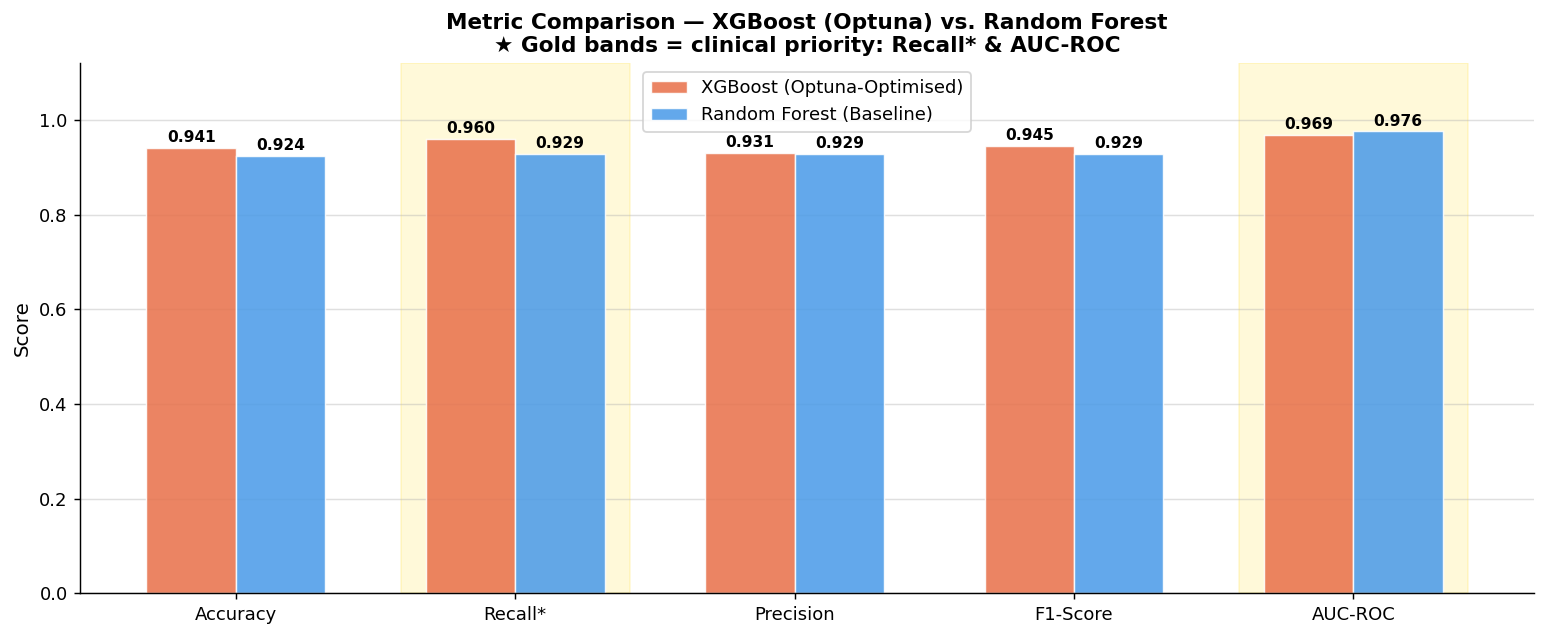

[✓] Saved → metric_comparison.png


In [19]:
metric_cols = ["Accuracy", "Recall*", "Precision", "F1-Score", "AUC-ROC"]
bar_data    = results_df[metric_cols].T

fig2, ax = plt.subplots(figsize=(12, 5))
x, w = np.arange(len(metric_cols)), 0.32

for i, (model_lbl, color) in enumerate(
        zip(bar_data.columns, [PALETTE["xgb"], PALETTE["rf"]])):
    bars = ax.bar(x + i*w, bar_data[model_lbl], width=w,
                  label=model_lbl, color=color, alpha=0.87,
                  edgecolor="white", linewidth=0.8)
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
                f"{b.get_height():.3f}", ha="center", va="bottom",
                fontsize=8.5, fontweight="bold")

# Highlight priority metrics
for idx in [metric_cols.index("Recall*"), metric_cols.index("AUC-ROC")]:
    ax.axvspan(idx - 0.25, idx + 0.25 + w, color="gold", alpha=0.15, zorder=0)

ax.set_xticks(x + w/2)
ax.set_xticklabels(metric_cols, fontsize=10)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score", fontsize=11)
ax.set_title(
    "Metric Comparison — XGBoost (Optuna) vs. Random Forest\n"
    "★ Gold bands = clinical priority: Recall* & AUC-ROC",
    fontsize=12, fontweight="bold",
)
ax.legend(fontsize=10)
ax.yaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("metric_comparison.png", bbox_inches="tight")
plt.show()
print("[✓] Saved → metric_comparison.png")


In [20]:
print(f"\n[7/7] SHAP analysis — {winner_name}")

explainer   = shap.TreeExplainer(winner_model)
shap_values = explainer.shap_values(winner_proc)

# For binary XGBoost → shap_values is 2-D directly
# For RF             → shap_values is a list [class0, class1]
if isinstance(shap_values, list):
    sv_disease = shap_values[1]            # disease class
else:
    sv_disease = shap_values

feat_names = FEATURE_NAMES if "XGBoost" in winner_name else list(X_raw.columns)
X_test_df  = pd.DataFrame(winner_proc, columns=feat_names)



[7/7] SHAP analysis — Random Forest (Baseline)


<Figure size 1300x910 with 0 Axes>

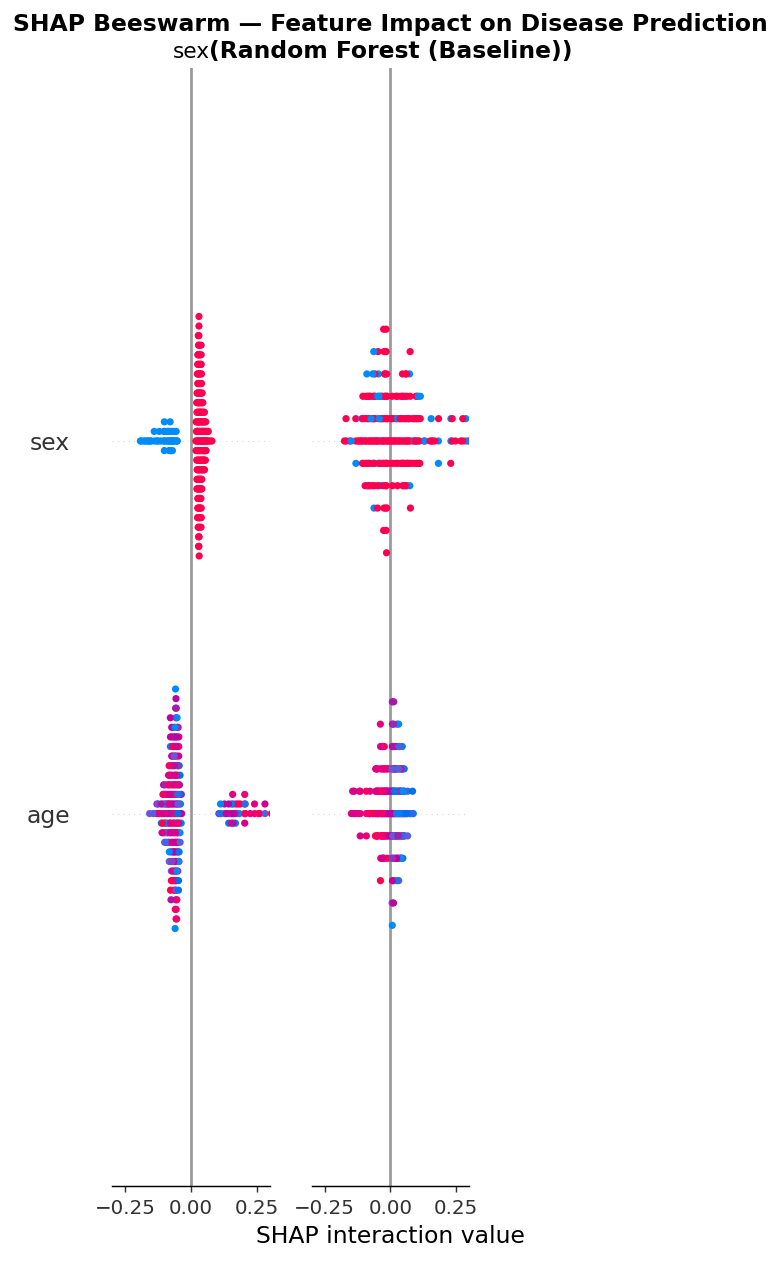

[✓] Saved → shap_beeswarm.png


In [21]:
plt.figure(figsize=(10, 7))
shap.summary_plot(
    sv_disease, X_test_df,
    plot_type   = "dot",
    show        = False,
    max_display = len(feat_names),
)
plt.title(
    f"SHAP Beeswarm — Feature Impact on Disease Prediction\n({winner_name})",
    fontsize=13, fontweight="bold",
)
plt.tight_layout()
plt.savefig("shap_beeswarm.png", bbox_inches="tight")
plt.show()
print("[✓] Saved → shap_beeswarm.png")


<Figure size 1300x910 with 0 Axes>

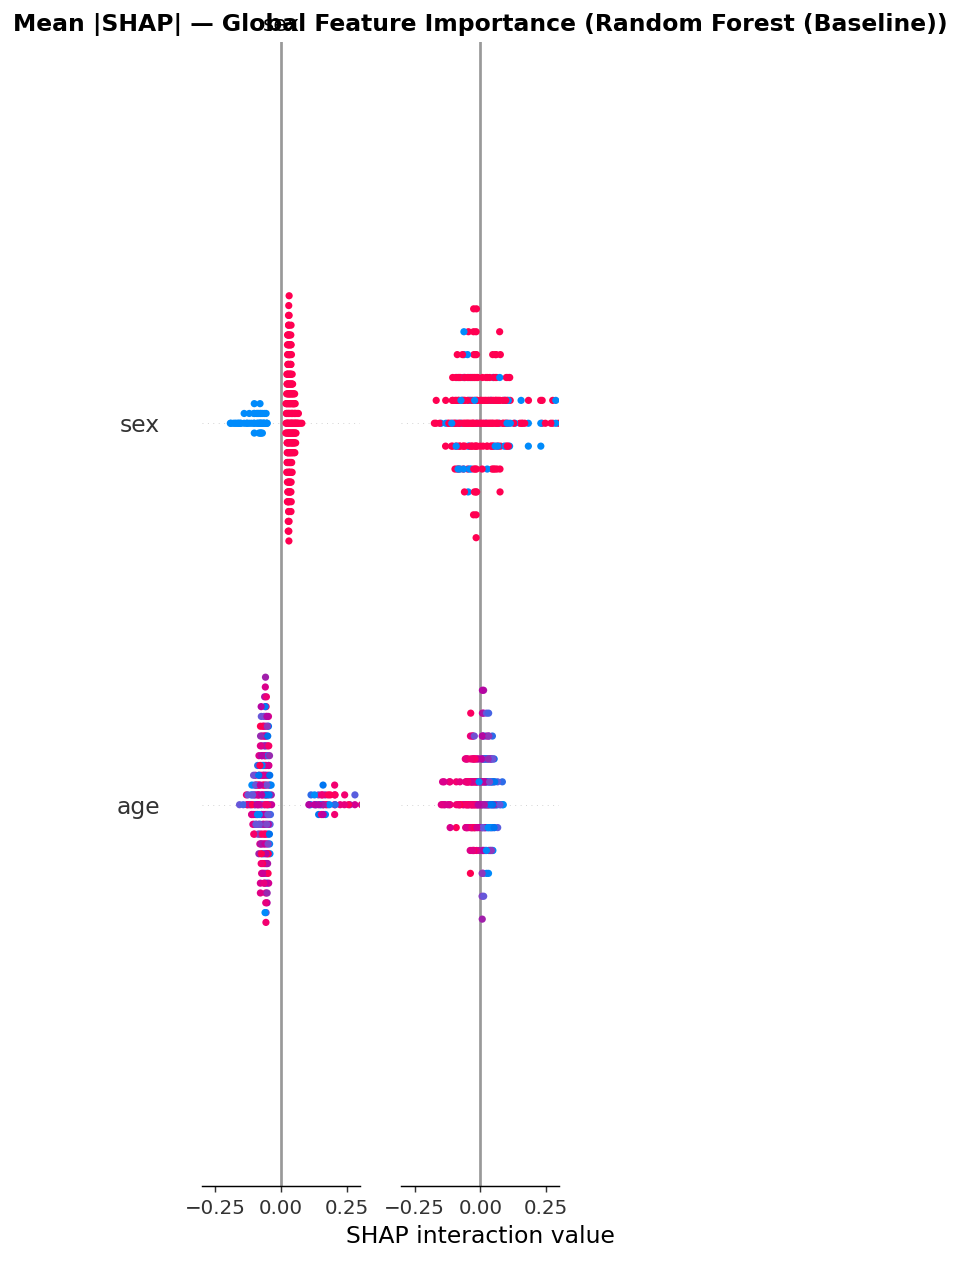

[✓] Saved → shap_bar.png


In [22]:
plt.figure(figsize=(10, 7))
shap.summary_plot(
    sv_disease, X_test_df,
    plot_type   = "bar",
    show        = False,
    max_display = len(feat_names),
)
plt.title(
    f"Mean |SHAP| — Global Feature Importance ({winner_name})",
    fontsize=13, fontweight="bold",
)
plt.tight_layout()
plt.savefig("shap_bar.png", bbox_inches="tight")
plt.show()
print("[✓] Saved → shap_bar.png")


[!] Optuna history plot skipped: 'Axes' object has no attribute 'set_size_inches'


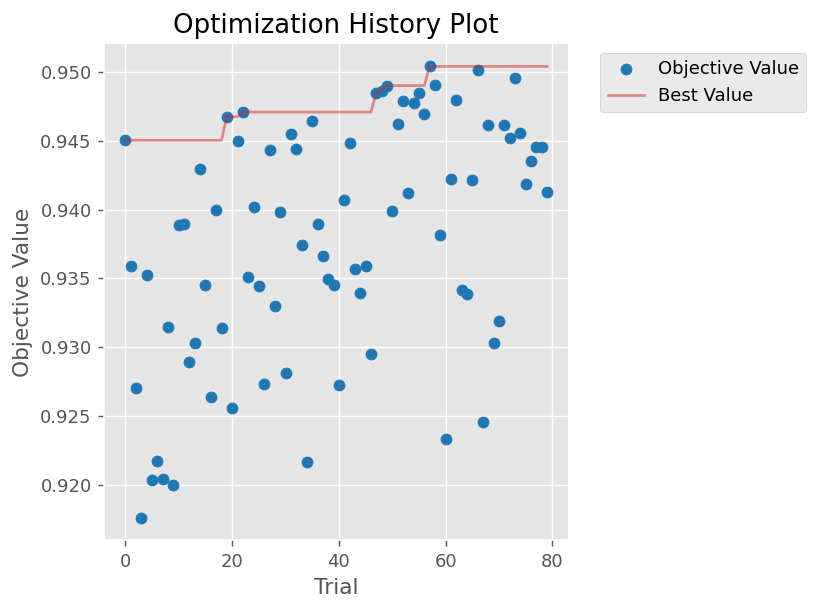

In [23]:
try:
    fig_opt = optuna.visualization.matplotlib.plot_optimization_history(study)
    fig_opt.set_size_inches(10, 4)
    plt.title("Optuna Optimisation History — XGBoost AUC-ROC per Trial",
              fontsize=12)
    plt.tight_layout()
    plt.savefig("optuna_history.png", bbox_inches="tight")
    plt.show()
    print("[✓] Saved → optuna_history.png")
except Exception as e:
    print(f"[!] Optuna history plot skipped: {e}")

In [24]:
print("\n" + "=" * 70)
print("  PIPELINE COMPLETE — FINAL RESULTS SUMMARY")
print("=" * 70)
print(results_df.to_string())
print(f"\n  Winner (AUC-ROC) : {winner_name}")
print(f"  Best Optuna CV AUC-ROC : {study.best_value:.4f}")
print(f"  Best Optuna params     : {best_params}")
print("\n  Saved artefacts:")
for f in ["confusion_roc.png", "metric_comparison.png",
          "shap_beeswarm.png", "shap_bar.png", "optuna_history.png"]:
    print(f"    • {f}")
print("\n  Key Clinical Insight: Review 'Recall*' — a low recall means the")
print("  model is missing actual heart disease patients (false negatives),")
print("  the most dangerous error type in medical screening.")
print("=" * 70)


  PIPELINE COMPLETE — FINAL RESULTS SUMMARY
                            Accuracy  Recall*  Precision  F1-Score  AUC-ROC
Model                                                                      
XGBoost (Optuna-Optimised)    0.9412   0.9603     0.9308    0.9453   0.9690
Random Forest (Baseline)      0.9244   0.9286     0.9286    0.9286   0.9761

  Winner (AUC-ROC) : Random Forest (Baseline)
  Best Optuna CV AUC-ROC : 0.9504
  Best Optuna params     : {'n_estimators': 356, 'max_depth': 7, 'learning_rate': 0.127397824177842, 'subsample': 0.6148985575257964, 'colsample_bytree': 0.6639400789323814, 'min_child_weight': 1, 'gamma': 0.022904229688582595, 'reg_alpha': 0.7268865388800891, 'reg_lambda': 4.46727253981053, 'objective': 'binary:logistic', 'eval_metric': 'logloss', 'random_state': 42}

  Saved artefacts:
    • confusion_roc.png
    • metric_comparison.png
    • shap_beeswarm.png
    • shap_bar.png
    • optuna_history.png

  Key Clinical Insight: Review 'Recall*' — a low recall me